### Sentiment Analysis Using Neutral Networks
By Stephanie Nguyen

### A1. Research Question 

How accurately can a neural network, using NLP techniques and a prescribed method such as a Bidirectional LSTM, predict sentiment from combined IMDb, Amazon, and Yelp reviews?

### A2. Objectives or Goals
A neural network model using Bidirectional Long Short-Term Memory (Bi-LSTM) will be developed to classify the sentiment, positive or negative, of reviews from the combined IMDb, Amazon, and Yelp data sets. The objectives are to preprocess the reviews using NLP techniques like tokenization, stopword removal, and lemmatization, convert the text into numerical data using word embeddings for input to the BiLSTM, optimize the model, and evaluate its performance to ensure accurate and reliable sentiment predictions.

### A3. Prescribed Network
The neural network implemented for text classification on the selected dataset is a Bidirectional Long Short-Term Memory (BiLSTM), designed to produce sentiment predictions from review sequences. This network, a type of Recurrent Neural Network (RNN), improves upon traditional RNNs by processing sequences in both forward and backward directions simultaneously, enabling it to capture contextual information more effectively for accurate predictions.

### PACKAGES AND LIBRARIES LIST

In [ ]:
# pip install tensorflow

In [ ]:
# pip install --upgrade pip

In [ ]:
# pip install nltk

In [ ]:
# Importing all libraries and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import csv
import re

# ignore warnings
import warnings
warnings.filterwarnings("ignore")

# train/test split
from sklearn.model_selection import train_test_split

# RSME error metric
from sklearn.metrics import mean_squared_error as mse
from math import sqrt

# National Language Toolkit (NLTK) - statistical package
import nltk
# nltk.download('punkt_tab')
# nltk.download('stopwords')
# nltk.download('wordnet')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer as wnl

import tensorflow as tf
import tensorflow.keras

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# Load/import UCI Labeled Sentences Data Sets
# The sentences come from 3 different websites: imdb, amazon, and yelp

amazon = pd.read_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\13. Analyzing Sentiment through NLP (Python)\Data\amazon_cells_labelled.txt", sep='\t', header=None, quoting=csv.QUOTE_NONE)
imdb = pd.read_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\13. Analyzing Sentiment through NLP (Python)\Data\imdb_labelled.txt", sep='\t', header=None, quoting=csv.QUOTE_NONE)
yelp = pd.read_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\13. Analyzing Sentiment through NLP (Python)\Data\yelp_labelled.txt", sep='\t', header=None, quoting=csv.QUOTE_NONE)

#### Preview the data set

In [ ]:
# Get the number of rows and columns in the dataframe
amazon.shape

(1000, 2)

In [ ]:
imdb.shape

(1000, 2)

In [ ]:
yelp.shape

(1000, 2)

In [ ]:
# Assign column heads and review the data
amazon.columns = ['Review','Sentiment']
imdb.columns = ['Review','Sentiment']
yelp.columns = ['Review','Sentiment']

In [ ]:
# concat files
df = pd.concat([yelp, imdb, amazon], ignore_index=True, axis=0)

In [ ]:
df.shape

(3000, 2)

In [ ]:
df.head

<bound method NDFrame.head of                                                  Review  Sentiment
0                              Wow... Loved this place.          1
1                                    Crust is not good.          0
2             Not tasty and the texture was just nasty.          0
3     Stopped by during the late May bank holiday of...          1
4     The selection on the menu was great and so wer...          1
...                                                 ...        ...
2995  The screen does get smudged easily because it ...          0
2996  What a piece of junk.. I lose more calls on th...          0
2997                       Item Does Not Match Picture.          0
2998  The only thing that disappoint me is the infra...          0
2999  You can not answer calls with the unit, never ...          0

[3000 rows x 2 columns]>

In [ ]:
# get overview of columns and data types in dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Review     3000 non-null   object
 1   Sentiment  3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.0+ KB


#### Data Cleaning
The data set is checked for null and duplicated values during the data cleaning phase.

In [ ]:
# detect null values
df.isnull().sum()

Review       0
Sentiment    0
dtype: int64

In [ ]:
# get duplicates across all columns
df.duplicated().value_counts()

False    2983
True       17
Name: count, dtype: int64

In [ ]:
duplicates = df.duplicated()

# View the duplicate reviews
print(df[duplicates])

                                                 Review  Sentiment
814                                  I love this place.          1
816                              The food was terrible.          0
843                                    I won't be back.          0
846                   I would not recommend this place.          0
1363                   Definitely worth checking out.            1
1585                                 Not recommended.            0
1788                                            10/10            1
2285                                      Great phone!.          1
2407                                       Works great.          1
2524                                      Works great!.          1
2543                            Don't buy this product.          0
2744  If you like a loud buzzing to override all you...          0
2748                                      Does not fit.          0
2778                              This is a great deal.       

The duplicate reviews were retained to ensure the sentiment analysis remains comprehensive and unbiased.

### B1. Data Exploration

In [ ]:
# Lowercase reviews
df['Review'] = df['Review'].str.lower()
df.head

<bound method NDFrame.head of                                                  Review  Sentiment
0                              wow... loved this place.          1
1                                    crust is not good.          0
2             not tasty and the texture was just nasty.          0
3     stopped by during the late may bank holiday of...          1
4     the selection on the menu was great and so wer...          1
...                                                 ...        ...
2995  the screen does get smudged easily because it ...          0
2996  what a piece of junk.. i lose more calls on th...          0
2997                       item does not match picture.          0
2998  the only thing that disappoint me is the infra...          0
2999  you can not answer calls with the unit, never ...          0

[3000 rows x 2 columns]>

<b>Unusual Characters</b><br>

To prepare the data for sentiment analysis, unusual characters such as punctuation will be removed, as they do not contribute to meaningful analysis. Only word characters (letters and numbers) and whitespace characters (such as spaces and tabs, which aid in readability) will be retained.

In [ ]:
# Remove all punctuation by identifying characters that are neither word characters nor whitespace and replacing them with an empty string
df['Review'] = df['Review'].apply(lambda x: re.sub(r'[^\w\s]','',x))

In [ ]:
df.head

<bound method NDFrame.head of                                                  Review  Sentiment
0                                  wow loved this place          1
1                                     crust is not good          0
2              not tasty and the texture was just nasty          0
3     stopped by during the late may bank holiday of...          1
4     the selection on the menu was great and so wer...          1
...                                                 ...        ...
2995  the screen does get smudged easily because it ...          0
2996  what a piece of junk i lose more calls on this...          0
2997                        item does not match picture          0
2998  the only thing that disappoint me is the infra...          0
2999  you can not answer calls with the unit never w...          0

[3000 rows x 2 columns]>

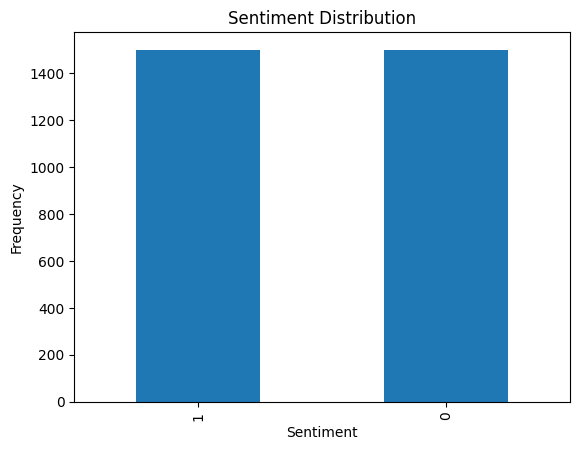

In [ ]:
# Distribution of sentiments; score is either 1 (positive) or 0 (negative)
df['Sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel('Sentiment')
plt.ylabel('Frequency')
plt.show()

In [ ]:
print(df['Sentiment'].value_counts())

Sentiment
1    1500
0    1500
Name: count, dtype: int64


### B2. Tokenization
The tokenization process, performed using the Natural Language Toolkit (NLTK) package, is a critical step in normalizing text for analysis. It breaks sentences into individual words, or tokens, allowing the review text to be structured and analyzed for sentiment more effectively.

In [ ]:
# Define a function to tokenize text
def tokenization(text):
    return word_tokenize(text)  # Tokenize each string into a list of words

# Apply the tokenization function to the reviews column
df['Tokens'] = df['Review'].apply(tokenization)
df.head

<bound method NDFrame.head of                                                  Review  Sentiment  \
0                                  wow loved this place          1   
1                                     crust is not good          0   
2              not tasty and the texture was just nasty          0   
3     stopped by during the late may bank holiday of...          1   
4     the selection on the menu was great and so wer...          1   
...                                                 ...        ...   
2995  the screen does get smudged easily because it ...          0   
2996  what a piece of junk i lose more calls on this...          0   
2997                        item does not match picture          0   
2998  the only thing that disappoint me is the infra...          0   
2999  you can not answer calls with the unit never w...          0   

                                                 Tokens  
0                             [wow, loved, this, place]  
1            

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['Review'])

<b> Stopwords </b><br>
Stopwords, such as "is," "the," "and," or "but," are common filler words that do not contribute meaningful information to the sentiment of reviews and can add noise to the analysis. Removing these words during preprocessing is essential to focus on terms that carry relevant sentiment information and improve model efficiency.

In [ ]:
# Remove stopwords
stop_words = set(stopwords.words('english'))

def sw(tokens):
    return [word for word in tokens if word not in stop_words]

# Apply the lemmanization function to the tokens column
df['Tokens'] = df['Tokens'].apply(sw)
df.head

<bound method NDFrame.head of                                                  Review  Sentiment  \
0                                  wow loved this place          1   
1                                     crust is not good          0   
2              not tasty and the texture was just nasty          0   
3     stopped by during the late may bank holiday of...          1   
4     the selection on the menu was great and so wer...          1   
...                                                 ...        ...   
2995  the screen does get smudged easily because it ...          0   
2996  what a piece of junk i lose more calls on this...          0   
2997                        item does not match picture          0   
2998  the only thing that disappoint me is the infra...          0   
2999  you can not answer calls with the unit never w...          0   

                                                 Tokens  
0                                   [wow, loved, place]  
1            

<b> Lemmatization </b> <br>
Lemmatization is a preprocessing step in natural language processing (NLP) that reduces words to their base or root form, ensuring variations like "running," "runs," and "ran" are represented as a single term, such as "run." For this sentiment analysis, lemmatization was applied using the Natural Language Toolkit (NLTK) to standardize the review text.

In [ ]:
# Lemmantization
lemmatizer = wnl()

def lemmatization(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens] 

# Apply the lemmanization function to the tokens column
df['Tokens'] = df['Tokens'].apply(lemmatization)
df.head

<bound method NDFrame.head of                                                  Review  Sentiment  \
0                                  wow loved this place          1   
1                                     crust is not good          0   
2              not tasty and the texture was just nasty          0   
3     stopped by during the late may bank holiday of...          1   
4     the selection on the menu was great and so wer...          1   
...                                                 ...        ...   
2995  the screen does get smudged easily because it ...          0   
2996  what a piece of junk i lose more calls on this...          0   
2997                        item does not match picture          0   
2998  the only thing that disappoint me is the infra...          0   
2999  you can not answer calls with the unit never w...          0   

                                                 Tokens  
0                                   [wow, loved, place]  
1            

In [ ]:
# Add word count column to data frame
df['word_count'] = df['Tokens'].apply(lambda x: len(x))
df.head

<bound method NDFrame.head of                                                  Review  Sentiment  \
0                                  wow loved this place          1   
1                                     crust is not good          0   
2              not tasty and the texture was just nasty          0   
3     stopped by during the late may bank holiday of...          1   
4     the selection on the menu was great and so wer...          1   
...                                                 ...        ...   
2995  the screen does get smudged easily because it ...          0   
2996  what a piece of junk i lose more calls on this...          0   
2997                        item does not match picture          0   
2998  the only thing that disappoint me is the infra...          0   
2999  you can not answer calls with the unit never w...          0   

                                                 Tokens  word_count  
0                                   [wow, loved, place]    

In [ ]:
# Create a list of all words in reviews
wordlist = []

for words in df['Tokens']:
    for word in words:
       wordlist.append(word)

# Convert list into pandas series
wordlist = pd.Series(wordlist)
print(wordlist)

0           wow
1         loved
2         place
3         crust
4          good
          ...  
18588    answer
18589      call
18590      unit
18591     never
18592    worked
Length: 18593, dtype: object


In [ ]:
# Find number of unique words in tokenized reviews
wordlist.describe()

count     18593
unique     4861
top        good
freq        226
dtype: object

In [ ]:
# Create a list of unique words
unique_words = wordlist.unique()
print(unique_words)

['wow' 'loved' 'place' ... 'port' 'irda' 'answer']


<b>Vocabulary Size</b><br>
Vocabulary size refers to the total number of unique words in a dataset after preprocessing steps such as lowercasing, removing unusual characters and stopwords, and tokenization. It plays a critical role in natural language processing (NLP) by defining the scope of text representation and directly influencing the model's complexity and performance.

In [ ]:
vocab_size = len(wordlist.unique())
print(vocab_size)

4861


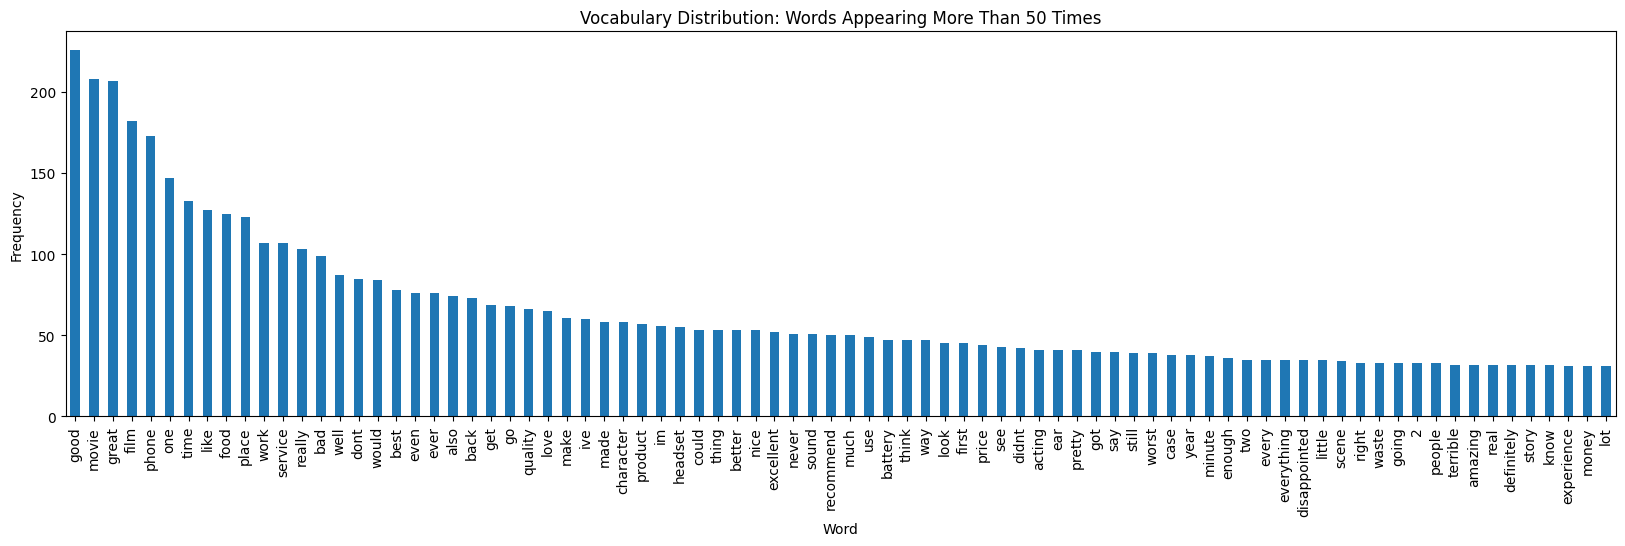

In [ ]:
# View vocabulary distribution of words that appear more than 50 times
plt.figure(figsize= (20, 5))
wordlist.value_counts().loc[lambda x: x > 30].plot(kind='bar')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.title('Vocabulary Distribution: Words Appearing More Than 50 Times')
plt.show()

<b>Word Embedding Length</b><br>
Given the size of the dataset and the requirements of the sentiment analysis task, the dimensionality of the word embedding was set to 100 to balance computational efficiency and the ability to capture meaningful word relationships (Xu, 2024).

In [ ]:
# Choose dimensionality for word embedding to be 100 
embedding_dim = 100

<b>Statistical Justification for Maximum Sequence Length</b><br>
The maximum sequence length was set to 14 words, capturing 95% of reviews while truncating only the longest 5%. This selection avoids excessive padding that would result from using the maximum review length of 41 words and aligns with the dataset’s structure, where most reviews are concise, with a median length of 5 words. This decision ensures a balance between preserving relevant information and maintaining model efficiency.

In [ ]:
# Compute the 95th percentile
input_length = np.percentile(df['Tokens'].apply(lambda x: len(x)), 95).astype(int)
print('95th Percentile Review Length: ', input_length)
print('Mean Sentence Length: ', (df['Tokens'].apply(lambda x: len(x))).mean().round(2))
print('Median Sentence Length: ', (df['Tokens'].apply(lambda x: len(x))).median().round(2))

max_sentence_length = max(df['Tokens'].apply(lambda x: len(x)))
print('Max Sentence Length: ', max_sentence_length)

95th Percentile Review Length:  14
Mean Sentence Length:  6.2
Median Sentence Length:  5.0
Max Sentence Length:  41


### B3. Padding Process
The padding process ensures all text sequences are the same length, which is required for TensorFlow and the neural network. Padding adds zeros to the end of shorter sequences to match the specified maximum length.

In this analysis, padding is applied after the text sequence, with zeros appended during preprocessing. This step ensures all input sequences are uniform before being passed to the model for training.

In [ ]:
words_to_index = {word:index for index,word in enumerate(unique_words)}
sequences = df['Tokens'].apply(lambda tokens: [words_to_index[token] for token in tokens if token in words_to_index])

print(sequences)

0                                     [0, 1, 2]
1                                        [3, 4]
2                                     [5, 6, 7]
3             [8, 9, 10, 11, 12, 13, 14, 15, 1]
4                              [16, 17, 18, 19]
                         ...                   
2995    [1976, 107, 4856, 1574, 40, 4006, 1876]
2996              [566, 2294, 4792, 1720, 4009]
2997                          [1241, 4098, 771]
2998          [186, 1174, 4857, 90, 4858, 4859]
2999               [4860, 1720, 4367, 94, 3118]
Name: Tokens, Length: 3000, dtype: object


In [ ]:
padded_sequences = pad_sequences(sequences, maxlen=14, padding='post', truncating='post')

print(padded_sequences)

[[   0    1    2 ...    0    0    0]
 [   3    4    0 ...    0    0    0]
 [   5    6    7 ...    0    0    0]
 ...
 [1241 4098  771 ...    0    0    0]
 [ 186 1174 4857 ...    0    0    0]
 [4860 1720 4367 ...    0    0    0]]


### B4. Categories of Sentiment
There are two sentiment categories: 1 for positive and 0 for negative. The final dense layer of the network uses a sigmoid activation function, which outputs a value between 0 and 1, making it suitable for binary classification.

In [ ]:
categories = len(df['Sentiment'].unique())
print('Number of categories of sentiment: ',categories)
print('Scores: ', df['Sentiment'].unique())

Number of categories of sentiment:  2
Scores:  [1 0]


### B5. Steps to Prepare the Data
The data preparation process involved several steps to ensure it was ready for analysis using neural network models and NLP techniques. First, the data underwent preprocessing, which included cleaning, exploratory data analysis (EDA), removal of punctuation, stopwords, lemmatization, tokenization, and padding to standardize sequence lengths. The X values consisted of the padded sequences, while the y values contained the corresponding sentiment labels.

The dataset was split into training, validation, and test sets based on industry averages. An initial 80/20 split separated the data into a training set and a temporary set. The temporary set was then split evenly into validation and test sets (50/50 split), resulting in 80% training data, 10% validation data, and 10% test data. This structured split ensures the data is optimized for training the neural network while maintaining sufficient validation and test sets for performance evaluation.

#### Splitting the Data

In [ ]:
# Train-test split
X = padded_sequences
y = df['Sentiment']

# Train and temporary set split, 80/20 split of the data
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

# Validation and test set split, 50/50 split of temporary set
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
print(X_train.shape)
print(y_train.shape)

print(X_val.shape)
print(y_val.shape)

print(X_test.shape)
print(y_test.shape)

(2400, 14)
(2400,)
(300, 14)
(300,)
(300, 14)
(300,)


### B6. Prepared Data Set

In [ ]:
# Export prepared data set
df.to_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\13. Analyzing Sentiment through NLP (Python)\Outputs\df.csv",index=False)

In [ ]:
# Export the training, validation, and test data set to csv files
X_train.tofile(r"C:\Users\steph\Documents\GitHub\Data Analysis\13. Analyzing Sentiment through NLP (Python)\Outputs\X_train.csv", sep = ',')
np.array(y_train).tofile(r"C:\Users\steph\Documents\GitHub\Data Analysis\13. Analyzing Sentiment through NLP (Python)\Outputs\X_val.csv", sep = ',')
np.array(y_val).tofile(r"C:\Users\steph\Documents\GitHub\Data Analysis\13. Analyzing Sentiment through NLP (Python)\Outputs\y_val.csv", sep = ',')
X_test.tofile(r"C:\Users\steph\Documents\GitHub\Data Analysis\13. Analyzing Sentiment through NLP (Python)\Outputs\X_test.csv", sep = ',')
np.array(y_test).tofile(r"CC:\Users\steph\Documents\GitHub\Data Analysis\13. Analyzing Sentiment through NLP (Python)\Outputs\y_test.csv", sep = ',')

In [ ]:
# Build the Bidirectional Long Short-Term Memory (Bi-LSTM) model
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=input_length, input_shape=(input_length,))) # Embedding layer
model.add(Bidirectional(LSTM(units=128, return_sequences=False))) # Bidirectional LSTM Layer
model.add(Dense(1, activation='sigmoid')) # Output layer for binary classification

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

### C1. Model Summary

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 14, 100)             │         486,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 256)                 │         234,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 720,853 (2.75 MB)

 Trainable params: 720,853 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

### C2. Network Architecture
The Bidirectional Long Short-Term Memory (BiLSTM) model consists of three layers: an Embedding Layer to convert words into dense vector representations, a Bidirectional LSTM Layer with 128 units to capture context in both directions, and a Dense Layer with a sigmoid activation function for binary classification. 

The architecture consists of the follow three layers:
1. Input Sequence/Embedding Layer - The Embedding Layer has 486,100 parameters.
2. Bidirectional LSTM (Bi-LSTM) Layer - The Bidirectional LSTM Layer has 234,496 parameters.
3. Output/ Dense Layer - The Dense Layer has 257 parameters.

As a result, there is a total of 720,853 trainable parameters. 

### C3. Hyperparameters
<b>Activation Function</b><br>
The sigmoid activation function in the output layer was chosen for its ability to output probabilities between 0 and 1, making it ideal for binary sentiment classification and ensuring compatibility with the binary crossentropy loss function for accurate predictions.

<b>Number of Nodes Per Layer</b><br>
In the Bidirectional LSTM layer, 128 units were chosen to provide sufficient capacity for capturing contextual dependencies within sequences, while the embedding layer was designed to handle input sequences of length 14, ensuring the model efficiently processes the padded text data for sentiment analysis.

<b>Loss Function</b><br>
Binary crossentropy was selected as the loss function because it is specifically designed for binary classification tasks and optimizes the model to produce accurate probabilistic outputs.

<b>Optimizer</b><br>
The Adam optimizer was selected for its efficiency in gradient descent, offering faster convergence and reliable performance, making it ideal for sentiment analysis tasks.

<b>Stopping Criteria</b><br>
Early stopping was implemented with a patience of 2 epochs to monitor the validation loss and stop training when no improvement is detected. This approach prevents overfitting, ensures the model generalizes well to unseen data, and optimizes training efficiency.

<b>Evaluation Metric</b><br>
Accuracy was chosen as the evaluation metric for this analysis because it effectively measures the proportion of correctly classified reviews, making it a straightforward and interpretable metric for binary sentiment classification tasks.

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=2)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.5646 - loss: 0.6787 - val_accuracy: 0.7400 - val_loss: 0.5013
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8863 - loss: 0.3077 - val_accuracy: 0.7600 - val_loss: 0.4636
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9498 - loss: 0.1487 - val_accuracy: 0.8000 - val_loss: 0.5317
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9746 - loss: 0.0827 - val_accuracy: 0.7967 - val_loss: 0.6567


### D1. Stopping Criteria
Implementing stopping criteria, such as early stopping, optimizes the number of epochs by monitoring the validation loss during training. In the code, early stopping is configured with patience=2, meaning the training process halts if the validation loss does not improve for two consecutive epochs, even though the maximum number of epochs is set to 20.

### D2. Fitness
The fitness of the model was assessed by evaluating its performance on the training, validation, and test datasets. The training loss decreased steadily across epochs, indicating that the model was effectively learning the patterns in the data. However, the validation loss began to increase after the first epoch, suggesting the onset of overfitting as the model started to memorize the training data rather than generalizing to unseen data.

To address overfitting, early stopping was implemented with a patience of 2 epochs, which monitored the validation loss and halted training when no improvement was observed. This ensured the model was preserved at its optimal performance point, preventing further overfitting. Additionally, the final test accuracy of 80% indicated that the model generalized well to unseen data, confirming its fitness for the sentiment analysis task. These steps ensured a balance between achieving high accuracy and maintaining generalization to new data.

### D3. Training Process

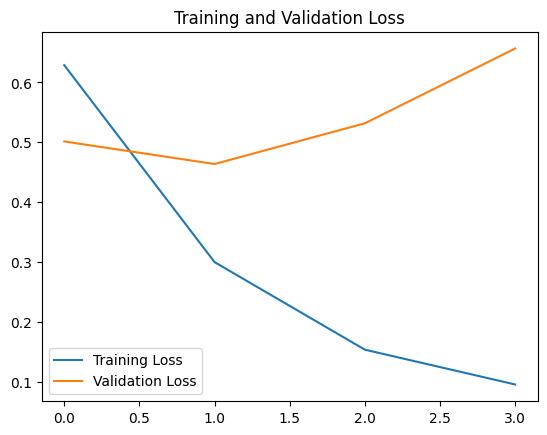

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.savefig('Training and Validation Loss.png')
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print('Test Accuracy: ', test_accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7924 - loss: 0.8493
Test Accuracy:  0.8066666722297668


### D4. Predictive Accuracy
The predictive accuracy of the model on the test set is roughly 80%, indicating that the model correctly classified the sentiment of 80% of the reviews in the unseen test data. This result demonstrates that the Bidirectional Long Short-Term Memory (Bi-LSTM) network effectively captured the relationships and context within the review text and generalized well to new data. While there is room for further optimization, the model provides a strong foundation for sentiment analysis and meets the primary objectives of the analysis by delivering reliable and accurate predictions.

### F. Functionality
The Bidirectional Long Short-Term Memory (Bi-LSTM) neural network effectively addressed the research question by capturing context from both forward and backward directions in text sequences, enabling accurate sentiment classification for IMDb, Amazon, and Yelp reviews. The architecture, consisting of an embedding layer, a Bidirectional LSTM layer, and a sigmoid-activated output layer, allowed the model to process sequential data efficiently and generalize well to unseen reviews. This alignment of functionality with the research question ensured the network produced reliable sentiment predictions while balancing complexity and performance.

### G. Recommendations
With a model accuracy of 80%, the Bidirectional Long Short-Term Memory (Bi-LSTM) model demonstrates strong performance and is suitable for production use in sentiment analysis. While the model's accuracy is strong, there is room for improvement, which can be achieved through additional hyperparameter tuning to further optimize its performance and achieve even higher accuracy. Potential improvements include adjusting the number of units in the Bidirectional LSTM layer, such as increasing from 128 to 256 units to enhance the model's capacity to capture complex patterns, and adding a dropout layer to reduce overfitting and improve generalization.

### I. Sources for Third-Party Code
Anishnama. (2023, May 18). Understanding bidirectional lstm for sequential data processing. Medium. https://medium.com/@anishnama20/understanding-bidirectional-lstm-for-sequential-data-processing-b83d6283befc

Elleh, F. (Director). (n.d.-a). D213 Task 2 Building NN Model in Python [Video recording]. https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=1b9aff54-735f-456a-a6b4-b11b00eb8d2f

Elleh, F. (Director). (n.d.-b). D213 Task 2 Data Preprocessing in Python [Video recording]. https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=8639374a-964b-4ae9-b33b-b1210052c07d

Sewell, W. (Director). (n.d.-a). D213 SA Webinar 4 [Video recording]. https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=c2642337-7947-4e7c-aa8d-af7b01456876

Sewell, W. (Director). (n.d.-b). D213 Webinar 3 Transition [Video recording]. https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=ea04fe77-3e3a-4293-8e9f-af7a00f22a8c

Sewell, W. (Director). (n.d.-c). D213 Webinar 6 SA [Video recording]. https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=c3890312-a194-4f3a-b579-af8901300903

Sewell, W. (Director). (n.d.-d). Webinar 5 SA [Video recording]. https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=8502edc2-27b3-46ed-ab9c-af89012040ed

### J. Sources
Anishnama. (2023, May 18). Understanding bidirectional lstm for sequential data processing. Medium. https://medium.com/@anishnama20/understanding-bidirectional-lstm-for-sequential-data-processing-b83d6283befc

Elleh, F. (Director). (n.d.-a). D213 Task 2 Building NN Model in Python [Video recording]. https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=1b9aff54-735f-456a-a6b4-b11b00eb8d2f

Elleh, F. (Director). (n.d.-b). D213 Task 2 Data Preprocessing in Python [Video recording]. https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=8639374a-964b-4ae9-b33b-b1210052c07d

Sewell, W. (Director). (n.d.-a). D213 SA Webinar 4 [Video recording]. https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=c2642337-7947-4e7c-aa8d-af7b01456876

Sewell, W. (Director). (n.d.-b). D213 Webinar 3 Transition [Video recording]. https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=ea04fe77-3e3a-4293-8e9f-af7a00f22a8c

Sewell, W. (Director). (n.d.-c). D213 Webinar 6 SA [Video recording]. https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=c3890312-a194-4f3a-b579-af8901300903

Sewell, W. (Director). (n.d.-d). Webinar 5 SA [Video recording]. https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=8502edc2-27b3-46ed-ab9c-af89012040ed

Xu, Z. (2024, March 18). Dimensionality of Word Embeddings. Baeldung. https://www.baeldung.com/cs/dimensionality-word-embeddings
